In [1]:
#Import the Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load the Dataset
df = pd.read_csv("C:/Users/cherr/Downloads/archive/Telco-Customer-Churn.csv")


In [18]:
print(df.head())
print('=========================================')
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [61]:
#-------------------------------
#1.Handle the missing values.
#-------------------------------

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

## Fill missing values with median
df.fillna({'TotalCharges': df['TotalCharges'].median()}, inplace=True)

In [62]:
# -------------------------------
# 2. Remove Duplicates
# -------------------------------
df.drop_duplicates(inplace=True)

In [63]:
# -------------------------------
# 3. Data Type Conversion
# -------------------------------

# Convert SeniorCitizen to category
df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')
# Replacing SeniorCitizen
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})


In [64]:
# -------------------------------
# 4. Standardize Categorical Values
# -------------------------------

# Remove leading/trailing spaces
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()


In [65]:
# -------------------------------
# 5. Feature Engineering
# -------------------------------

# Create churn numeric column
df['Churn_Value'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [66]:
# Create tenure group
df = df.copy()
df['tenure'] = df['tenure'].fillna(0)
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 60, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5-6yr']
)


In [67]:

# # Tenure_Group (remove Unknown)
# df = df[df['Tenure_Group'] != 'Unknown']


Outliers Detected: 0
Lower Bound: -46.02499999999999
Upper Bound: 171.375

Number of Outliers Detected: 0


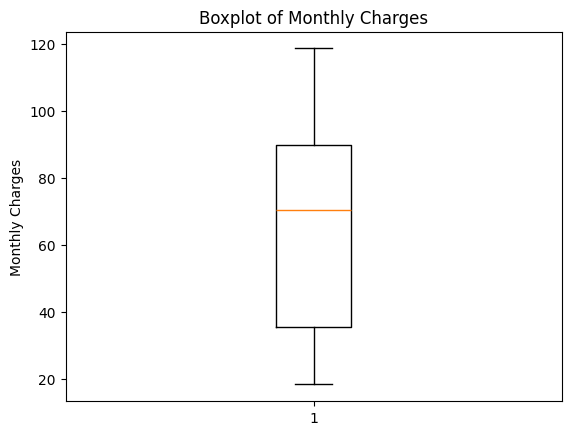

In [68]:
# -------------------------------
# 6. Outlier Handling
# -------------------------------

Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['MonthlyCharges'] < lower_bound) | 
              (df['MonthlyCharges'] > upper_bound)]

print("\nOutliers Detected:", len(outliers))
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of Outliers Detected:", len(outliers))
plt.figure()
plt.boxplot(df['MonthlyCharges'])
plt.title("Boxplot of Monthly Charges")
plt.ylabel("Monthly Charges")
plt.show()
# print("\nNOTE:")
# print("Outliers in MonthlyCharges are retained as they represent valid business scenarios such as premium plans and bundled services.")

In [70]:
# -------------------------------
# 7. Save Cleaned Data
# -------------------------------

df.to_csv("cleaned_telco_churn5.csv", index=False)

print("Data cleaning completed successfully!")

Data cleaning completed successfully!
